Random x and y test
Custom least squares:
m = 0.0565894814552717 b = 0.4488385800120373
Numpy least squares:
m = 0.05658948145527052 b = 0.4488385800120381

True line used to generate data:
m_true = 1.6840296179047165 b_true = -0.11561517542746991

Custom least squares fit:
m = 1.590107587335645 b = -0.06431601980469197

Numpy least squares fit:
m = 1.5901075873356452 b = -0.0643160198046925

First 10 residuals:
[-0.61653526 -0.81535879 -0.68413904  0.50509791  0.51166489 -0.35055315
 -0.07648167  0.39199278 -0.25837007  0.36568247]

Point with largest residual:
index = 41 X = 0.41000000000000003 Y = -0.39433940943425994 Y_pred = 0.5876280910029226 residual = -0.9819675004371825

Point with smallest residual:
index = 73 X = 0.73 Y = 1.0909225746132756 Y_pred = 1.0964625189503288 residual = -0.005539944337053182



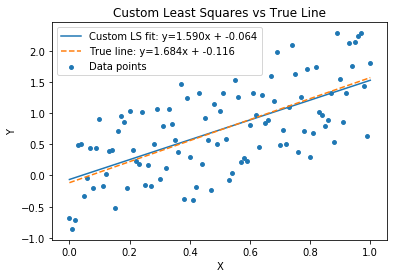

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def my_least_squares(x, y):
    n = len(x)

    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x**2)

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    b = (sum_y - m * sum_x) / n

    return m, b

#random x and y points
rng = np.random.default_rng(42)

X_rand = rng.random(30)
Y_rand = rng.random(30)

idx = np.argsort(X_rand)
X_rand = X_rand[idx]
Y_rand = Y_rand[idx]

m_custom_rand, b_custom_rand = my_least_squares(X_rand, Y_rand)

A_rand = np.vstack([X_rand, np.ones(len(X_rand))]).T
m_numpy_rand, b_numpy_rand = np.linalg.lstsq(A_rand, Y_rand, rcond=None)[0]

print("Random x and y test")
print("Custom least squares:")
print("m =", m_custom_rand, "b =", b_custom_rand)
print("Numpy least squares:")
print("m =", m_numpy_rand, "b =", b_numpy_rand)
print()

#random linear function with random error
m_true = rng.uniform(-5, 5)
b_true = rng.uniform(-2, 2)

X = np.arange(0, 1.0001, 0.01)

error = rng.random(len(X))
signs = rng.choice([-1, 1], size=len(X))

Y = m_true * X + b_true + signs * error

m_custom, b_custom = my_least_squares(X, Y)

A = np.vstack([X, np.ones(len(X))]).T
m_numpy, b_numpy = np.linalg.lstsq(A, Y, rcond=None)[0]

print("True line used to generate data:")
print("m_true =", m_true, "b_true =", b_true)
print()

print("Custom least squares fit:")
print("m =", m_custom, "b =", b_custom)
print()

print("Numpy least squares fit:")
print("m =", m_numpy, "b =", b_numpy)
print()

Y_pred = m_custom * X + b_custom

# residuals
residuals = Y - Y_pred
abs_residuals = np.abs(residuals)

i_max = np.argmax(abs_residuals)
i_min = np.argmin(abs_residuals)

print("First 10 residuals:")
print(residuals[:10])
print()

print("Point with largest residual:")
print("index =", i_max,
      "X =", X[i_max],
      "Y =", Y[i_max],
      "Y_pred =", Y_pred[i_max],
      "residual =", residuals[i_max])
print()

print("Point with smallest residual:")
print("index =", i_min,
      "X =", X[i_min],
      "Y =", Y[i_min],
      "Y_pred =", Y_pred[i_min],
      "residual =", residuals[i_min])
print()

plt.scatter(X, Y, s=15, label="Data points")
plt.plot(X, Y_pred, label=f"Custom LS fit: y={m_custom:.3f}x + {b_custom:.3f}")
plt.plot(X, m_true * X + b_true, "--", label=f"True line: y={m_true:.3f}x + {b_true:.3f}")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Custom Least Squares vs True Line")
plt.legend()
plt.show()

In [ ]:
#Used ChatGPT
#Helped in coming up with the function, syntax, and how to find residuals
#Prompt used: "Help with Python syntax for implementing a Least Squares function
# and checking the structure of the code"